# Descripción del Problema

**Problema:** 

**Objetivo:** Identificar segmentos de mercado en clientes de un centro comercial
basándose en características demográficas (edad, género) y comportamiento de 
compra (gasto anual). Esto permitirá estrategias de marketing dirigidas.

# Carga y Exploración Inicial (EDA)

In [1]:
import kagglehub

# Descarga la última versión del dataset de Kaggle
path = kagglehub.dataset_download("vjchoudhary7/customer-segmentation-tutorial-in-python")

# Imprime la ruta donde se encuentran descargados los archivos del dataset
print("Path to dataset files:", path)

/Users/fabianferrer/Documents/ITM/10 Semestre/Analisis de datos/Analisis_de_datos/venv-data-2/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


100%|██████████| 1.55k/1.55k [00:00<00:00, 2.28MB/s]

Extracting files...
Path to dataset files: /Users/fabianferrer/.cache/kagglehub/datasets/vjchoudhary7/customer-segmentation-tutorial-in-python/versions/1


In [3]:
# Como Kagglehub descarga los archivos en una carpeta oculta dentro del caché de usuario, 
# vamos a copiarlos a una ubicación más accesible para su análisis.

import shutil
import os

# Ruta donde Kagglehub guarda los archivos descargados
origen_path = r"/Users/fabianferrer/.cache/kagglehub/datasets/vjchoudhary7/customer-segmentation-tutorial-in-python/versions/1"

# Ruta destino donde queremos copiar los archivos
destino_path = r"/Users/fabianferrer/Documents/ITM/10 Semestre/Analisis de datos/Analisis_de_datos/Evaluación 4/Dataset"

# Copiar todos los archivos del origen al destino
for archivo in os.listdir(origen_path):
    ruta_origen = os.path.join(origen_path, archivo)
    ruta_destino = os.path.join(destino_path, archivo)
    if os.path.isfile(ruta_origen):
        shutil.copy2(ruta_origen, ruta_destino)

print("Archivos copiados exitosamente a:", destino_path)


Archivos copiados exitosamente a: /Users/fabianferrer/Documents/ITM/10 Semestre/Analisis de datos/Analisis_de_datos/Evaluación 4/Dataset


In [1]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score, silhouette_samples
from scipy.cluster.hierarchy import dendrogram, linkage
import warnings
warnings.filterwarnings('ignore')

# Configuración de visualización
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

df = pd.read_csv('Dataset/Mall_Customers.csv')

In [3]:
print("\nEXPLORACIÓN INICIAL DE DATOS")
print("-" * 80)
print(f"Forma del dataset: {df.shape}")
print(f"\nPrimeras filas:\n{df.head()}")
print(f"\nTipos de datos:\n{df.dtypes}")
print(f"\nEstadísticas descriptivas:\n{df.describe()}")
print(f"\nValores faltantes:\n{df.isnull().sum()}")


EXPLORACIÓN INICIAL DE DATOS
--------------------------------------------------------------------------------
Forma del dataset: (200, 5)

Primeras filas:
   CustomerID  Gender  Age  Annual Income (k$)  Spending Score (1-100)
0           1    Male   19                  15                      39
1           2    Male   21                  15                      81
2           3  Female   20                  16                       6
3           4  Female   23                  16                      77
4           5  Female   31                  17                      40

Tipos de datos:
CustomerID                 int64
Gender                    object
Age                        int64
Annual Income (k$)         int64
Spending Score (1-100)     int64
dtype: object

Estadísticas descriptivas:
       CustomerID         Age  Annual Income (k$)  Spending Score (1-100)
count  200.000000  200.000000          200.000000              200.000000
mean   100.500000   38.850000           60.560

# Analisis exploratorio de variables

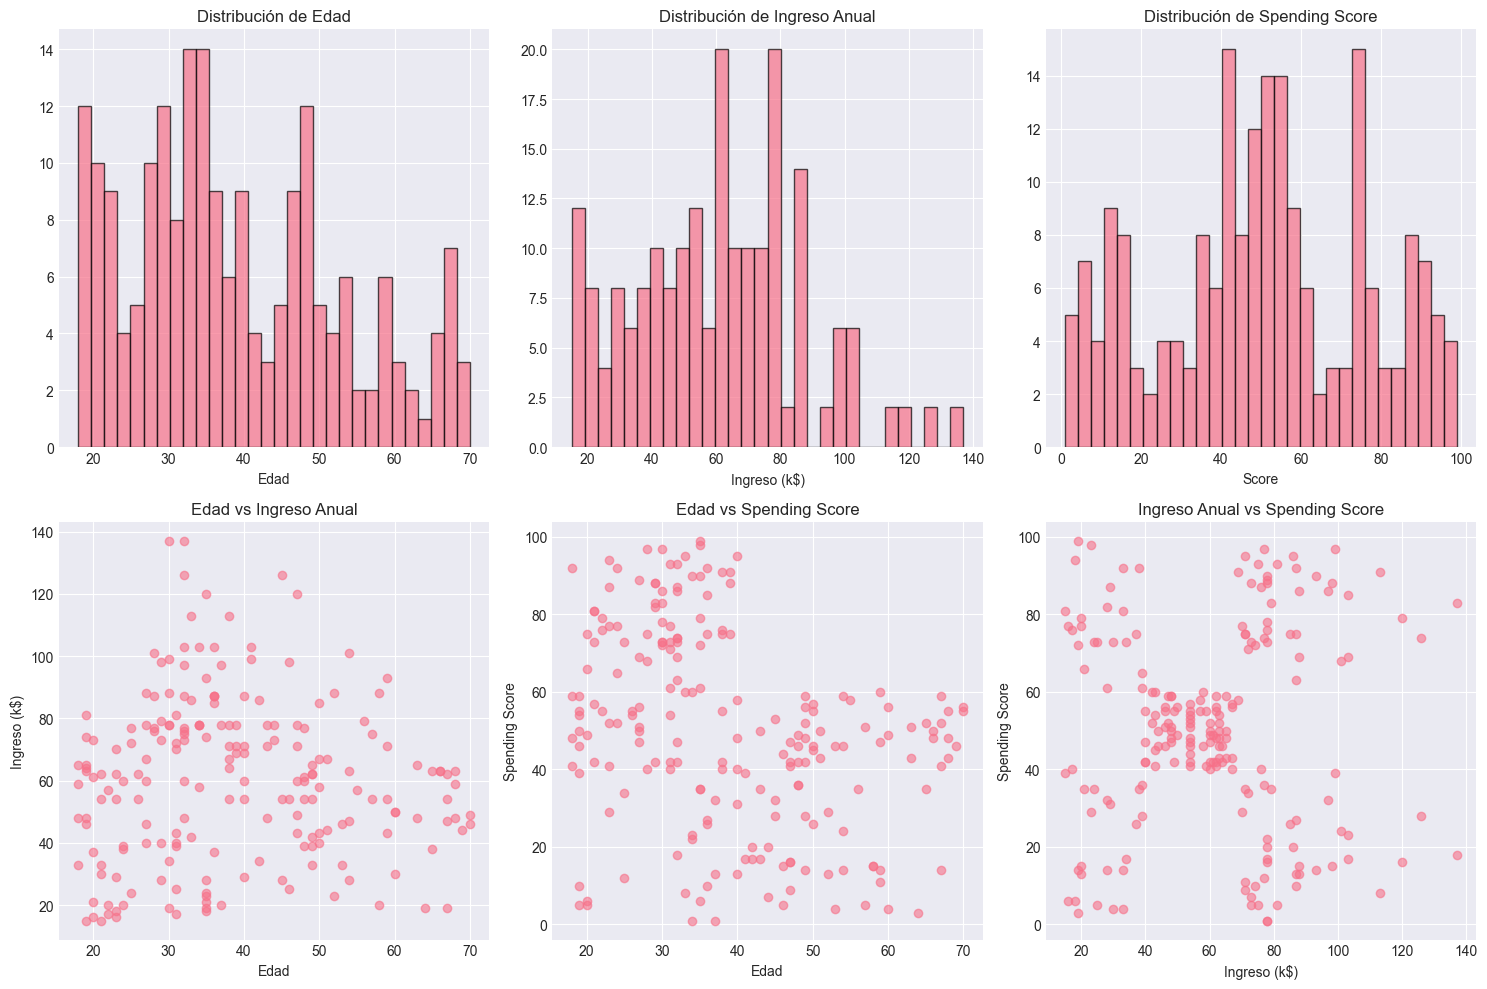

Gráficos exploratorios guardados como '01_eda_exploratorio.png'

Matriz de correlación:
                             Age  Annual Income (k$)  Spending Score (1-100)
Age                     1.000000           -0.012398               -0.327227
Annual Income (k$)     -0.012398            1.000000                0.009903
Spending Score (1-100) -0.327227            0.009903                1.000000


In [4]:
# Preparar datos numéricos para clustering
df_features = df[['Age', 'Annual Income (k$)', 'Spending Score (1-100)']].copy()

# Visualizaciones exploratorias
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

# Distribuciones univariadas
axes[0, 0].hist(df['Age'], bins=30, edgecolor='black', alpha=0.7)
axes[0, 0].set_title('Distribución de Edad')
axes[0, 0].set_xlabel('Edad')

axes[0, 1].hist(df['Annual Income (k$)'], bins=30, edgecolor='black', alpha=0.7)
axes[0, 1].set_title('Distribución de Ingreso Anual')
axes[0, 1].set_xlabel('Ingreso (k$)')

axes[0, 2].hist(df['Spending Score (1-100)'], bins=30, edgecolor='black', alpha=0.7)
axes[0, 2].set_title('Distribución de Spending Score')
axes[0, 2].set_xlabel('Score')

# Relaciones entre variables
axes[1, 0].scatter(df['Age'], df['Annual Income (k$)'], alpha=0.6)
axes[1, 0].set_title('Edad vs Ingreso Anual')
axes[1, 0].set_xlabel('Edad')
axes[1, 0].set_ylabel('Ingreso (k$)')

axes[1, 1].scatter(df['Age'], df['Spending Score (1-100)'], alpha=0.6)
axes[1, 1].set_title('Edad vs Spending Score')
axes[1, 1].set_xlabel('Edad')
axes[1, 1].set_ylabel('Spending Score')

axes[1, 2].scatter(df['Annual Income (k$)'], df['Spending Score (1-100)'], alpha=0.6)
axes[1, 2].set_title('Ingreso Anual vs Spending Score')
axes[1, 2].set_xlabel('Ingreso (k$)')
axes[1, 2].set_ylabel('Spending Score')

plt.tight_layout()
plt.savefig('01_eda_exploratorio.png', dpi=300, bbox_inches='tight')
plt.show()

print("Gráficos exploratorios guardados como '01_eda_exploratorio.png'")

# Análisis de correlación
print("\nMatriz de correlación:")
print(df_features.corr())

# Preparación de datos

In [5]:
scaler = StandardScaler()
df_scaled = scaler.fit_transform(df_features)
df_scaled = pd.DataFrame(df_scaled, columns=df_features.columns)

print("Datos normalizados (primeras 5 filas):")
print(df_scaled.head())

Datos normalizados (primeras 5 filas):
        Age  Annual Income (k$)  Spending Score (1-100)
0 -1.424569           -1.738999               -0.434801
1 -1.281035           -1.738999                1.195704
2 -1.352802           -1.700830               -1.715913
3 -1.137502           -1.700830                1.040418
4 -0.563369           -1.662660               -0.395980


# Metodo 1: K-MEANS

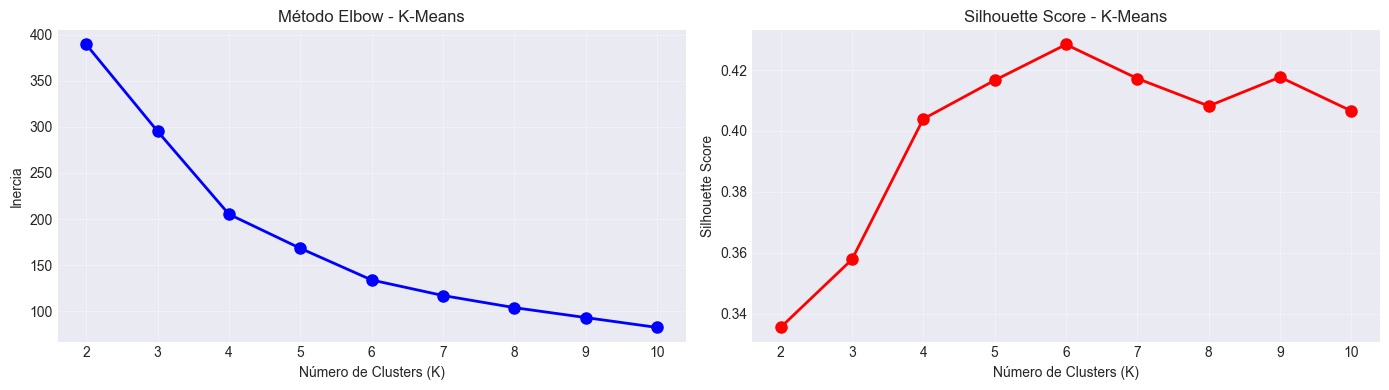


K óptimo seleccionado: 4
Silhouette Score K-Means: 0.4040


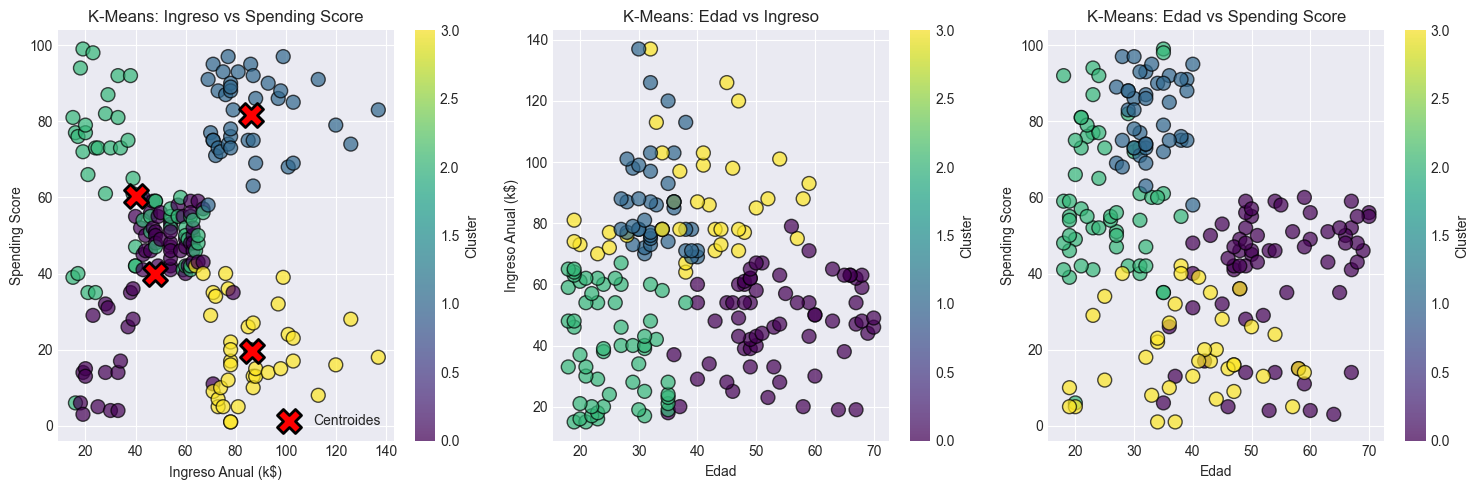


Resultados guardados como '03_kmeans_resultados_2d.png'


In [6]:
inertias = []
silhouette_scores = []
K_range = range(2, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(df_scaled)
    inertias.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(df_scaled, kmeans.labels_))

# Visualizar Elbow Method y Silhouette Score
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(K_range, inertias, 'bo-', linewidth=2, markersize=8)
axes[0].set_xlabel('Número de Clusters (K)')
axes[0].set_ylabel('Inercia')
axes[0].set_title('Método Elbow - K-Means')
axes[0].grid(True, alpha=0.3)

axes[1].plot(K_range, silhouette_scores, 'ro-', linewidth=2, markersize=8)
axes[1].set_xlabel('Número de Clusters (K)')
axes[1].set_ylabel('Silhouette Score')
axes[1].set_title('Silhouette Score - K-Means')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('02_kmeans_optimization.png', dpi=300, bbox_inches='tight')
plt.show()

# Usar K=4 como óptimo
k_optimal = 4
kmeans = KMeans(n_clusters=k_optimal, random_state=42, n_init=10)
kmeans_labels = kmeans.fit_predict(df_scaled)

silhouette_kmeans = silhouette_score(df_scaled, kmeans_labels)
print(f"\nK óptimo seleccionado: {k_optimal}")
print(f"Silhouette Score K-Means: {silhouette_kmeans:.4f}")

# Visualizar resultados K-Means
fig = plt.figure(figsize=(15, 5))

# 2D: Ingreso vs Spending Score
ax1 = fig.add_subplot(131)
scatter1 = ax1.scatter(df['Annual Income (k$)'], df['Spending Score (1-100)'], 
                       c=kmeans_labels, cmap='viridis', s=100, alpha=0.7, edgecolors='black')
ax1.scatter(scaler.inverse_transform(kmeans.cluster_centers_)[:, 1], 
           scaler.inverse_transform(kmeans.cluster_centers_)[:, 2], 
           c='red', marker='X', s=300, edgecolors='black', linewidths=2, label='Centroides')
ax1.set_xlabel('Ingreso Anual (k$)')
ax1.set_ylabel('Spending Score')
ax1.set_title('K-Means: Ingreso vs Spending Score')
ax1.legend()
plt.colorbar(scatter1, ax=ax1, label='Cluster')

# 2D: Edad vs Ingreso
ax2 = fig.add_subplot(132)
scatter2 = ax2.scatter(df['Age'], df['Annual Income (k$)'], 
                       c=kmeans_labels, cmap='viridis', s=100, alpha=0.7, edgecolors='black')
ax2.set_xlabel('Edad')
ax2.set_ylabel('Ingreso Anual (k$)')
ax2.set_title('K-Means: Edad vs Ingreso')
plt.colorbar(scatter2, ax=ax2, label='Cluster')

# 2D: Edad vs Spending Score
ax3 = fig.add_subplot(133)
scatter3 = ax3.scatter(df['Age'], df['Spending Score (1-100)'], 
                       c=kmeans_labels, cmap='viridis', s=100, alpha=0.7, edgecolors='black')
ax3.set_xlabel('Edad')
ax3.set_ylabel('Spending Score')
ax3.set_title('K-Means: Edad vs Spending Score')
plt.colorbar(scatter3, ax=ax3, label='Cluster')

plt.tight_layout()
plt.savefig('03_kmeans_resultados_2d.png', dpi=300, bbox_inches='tight')
plt.show()

print("\nResultados guardados como '03_kmeans_resultados_2d.png'")




# Metodo 2: DBSCAN


Justificación: DBSCAN es útil para:
- Encontrar clusters de formas arbitrarias (no solo esféricas como K-Means)
- Identificar outliers automáticamente
- No requiere especificar el número de clusters a priori



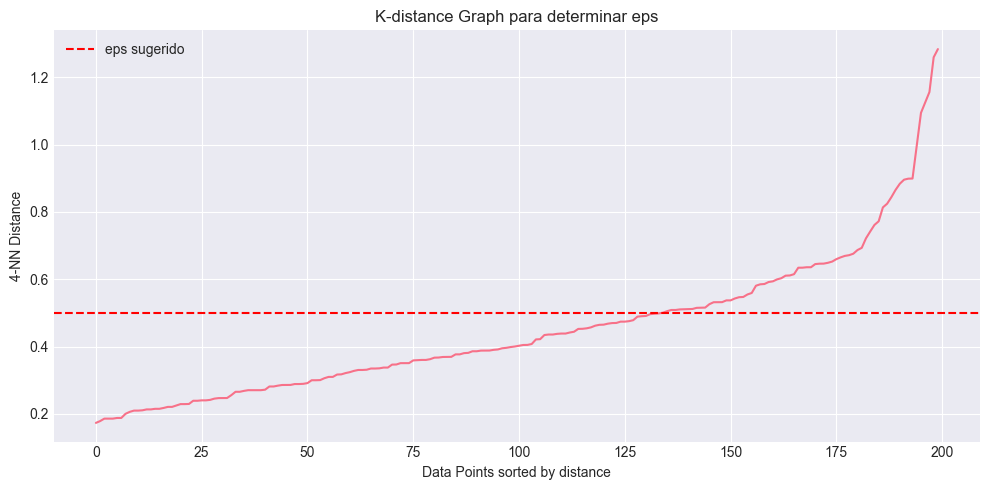


Parámetros DBSCAN: eps=0.5, min_samples=4
Número de clusters encontrados: 8
Número de outliers: 39 (19.50%)
Silhouette Score DBSCAN (sin outliers): 0.2815


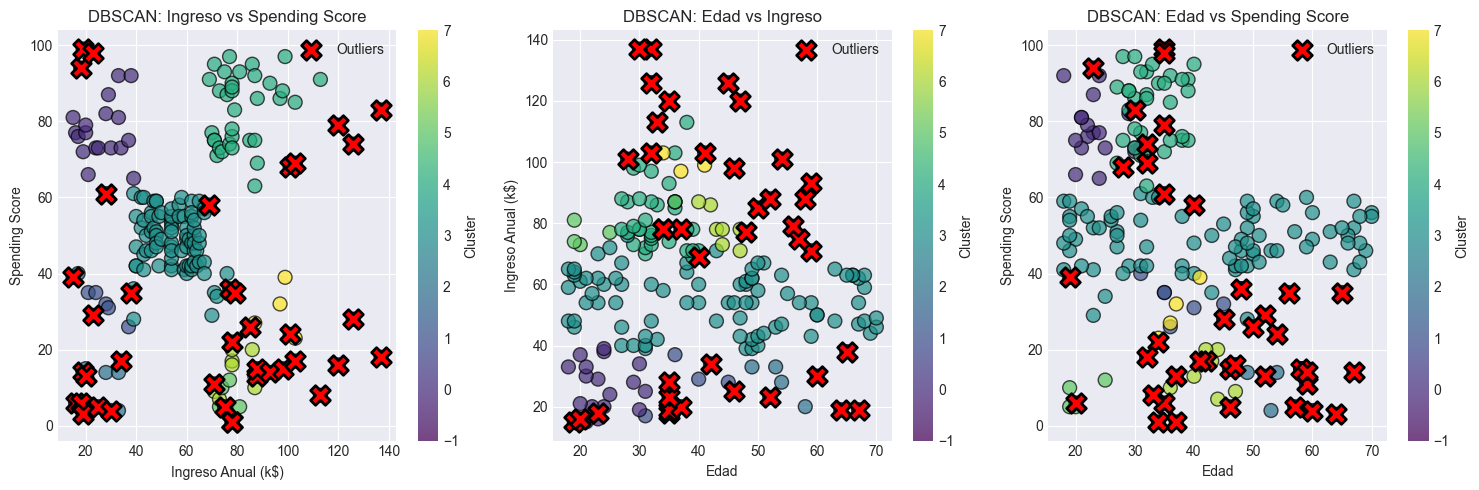


Resultados guardados como '05_dbscan_resultados_2d.png'


In [7]:
print("""
Justificación: DBSCAN es útil para:
- Encontrar clusters de formas arbitrarias (no solo esféricas como K-Means)
- Identificar outliers automáticamente
- No requiere especificar el número de clusters a priori
""")

# Encontrar eps óptimo usando k-distance graph
from sklearn.neighbors import NearestNeighbors
neighbors = NearestNeighbors(n_neighbors=4)
neighbors_fit = neighbors.fit(df_scaled)
distances, indices = neighbors_fit.kneighbors(df_scaled)
distances = np.sort(distances[:, 3], axis=0)

plt.figure(figsize=(10, 5))
plt.plot(distances)
plt.ylabel('4-NN Distance')
plt.xlabel('Data Points sorted by distance')
plt.title('K-distance Graph para determinar eps')
plt.axhline(y=0.5, color='r', linestyle='--', label='eps sugerido')
plt.legend()
plt.tight_layout()
plt.savefig('04_dbscan_kdistance.png', dpi=300, bbox_inches='tight')
plt.show()

# Aplicar DBSCAN con eps seleccionado
eps = 0.5
min_samples = 4
dbscan = DBSCAN(eps=eps, min_samples=min_samples)
dbscan_labels = dbscan.fit_predict(df_scaled)

n_clusters_dbscan = len(set(dbscan_labels)) - (1 if -1 in dbscan_labels else 0)
n_outliers = list(dbscan_labels).count(-1)

print(f"\nParámetros DBSCAN: eps={eps}, min_samples={min_samples}")
print(f"Número de clusters encontrados: {n_clusters_dbscan}")
print(f"Número de outliers: {n_outliers} ({n_outliers/len(df)*100:.2f}%)")

# Calcular silhouette score (excluyendo outliers)
dbscan_labels_valid = dbscan_labels[dbscan_labels != -1]
df_scaled_valid = df_scaled[dbscan_labels != -1]
if len(set(dbscan_labels_valid)) > 1 and len(dbscan_labels_valid) > 0:
    silhouette_dbscan = silhouette_score(df_scaled_valid, dbscan_labels_valid)
    print(f"Silhouette Score DBSCAN (sin outliers): {silhouette_dbscan:.4f}")

# Visualizar resultados DBSCAN
fig = plt.figure(figsize=(15, 5))

ax1 = fig.add_subplot(131)
scatter1 = ax1.scatter(df['Annual Income (k$)'], df['Spending Score (1-100)'], 
                       c=dbscan_labels, cmap='viridis', s=100, alpha=0.7, edgecolors='black')
outliers = df[dbscan_labels == -1]
ax1.scatter(outliers['Annual Income (k$)'], outliers['Spending Score (1-100)'], 
           c='red', marker='X', s=200, edgecolors='black', linewidths=2, label='Outliers')
ax1.set_xlabel('Ingreso Anual (k$)')
ax1.set_ylabel('Spending Score')
ax1.set_title('DBSCAN: Ingreso vs Spending Score')
ax1.legend()
plt.colorbar(scatter1, ax=ax1, label='Cluster')

ax2 = fig.add_subplot(132)
scatter2 = ax2.scatter(df['Age'], df['Annual Income (k$)'], 
                       c=dbscan_labels, cmap='viridis', s=100, alpha=0.7, edgecolors='black')
ax2.scatter(outliers['Age'], outliers['Annual Income (k$)'], 
           c='red', marker='X', s=200, edgecolors='black', linewidths=2, label='Outliers')
ax2.set_xlabel('Edad')
ax2.set_ylabel('Ingreso Anual (k$)')
ax2.set_title('DBSCAN: Edad vs Ingreso')
ax2.legend()
plt.colorbar(scatter2, ax=ax2, label='Cluster')

ax3 = fig.add_subplot(133)
scatter3 = ax3.scatter(df['Age'], df['Spending Score (1-100)'], 
                       c=dbscan_labels, cmap='viridis', s=100, alpha=0.7, edgecolors='black')
ax3.scatter(outliers['Age'], outliers['Spending Score (1-100)'], 
           c='red', marker='X', s=200, edgecolors='black', linewidths=2, label='Outliers')
ax3.set_xlabel('Edad')
ax3.set_ylabel('Spending Score')
ax3.set_title('DBSCAN: Edad vs Spending Score')
ax3.legend()
plt.colorbar(scatter3, ax=ax3, label='Cluster')

plt.tight_layout()
plt.savefig('05_dbscan_resultados_2d.png', dpi=300, bbox_inches='tight')
plt.show()

print("\nResultados guardados como '05_dbscan_resultados_2d.png'")

# Metodo 3: Jerarquico


Justificación: Clustering jerárquico es útil para:
- Visualizar la estructura dendrítica de los datos
- Entender las relaciones entre clusters
- Flexibilidad en la selección del número final de clusters
- Diferentes métodos de enlace capturan diferentes estructuras



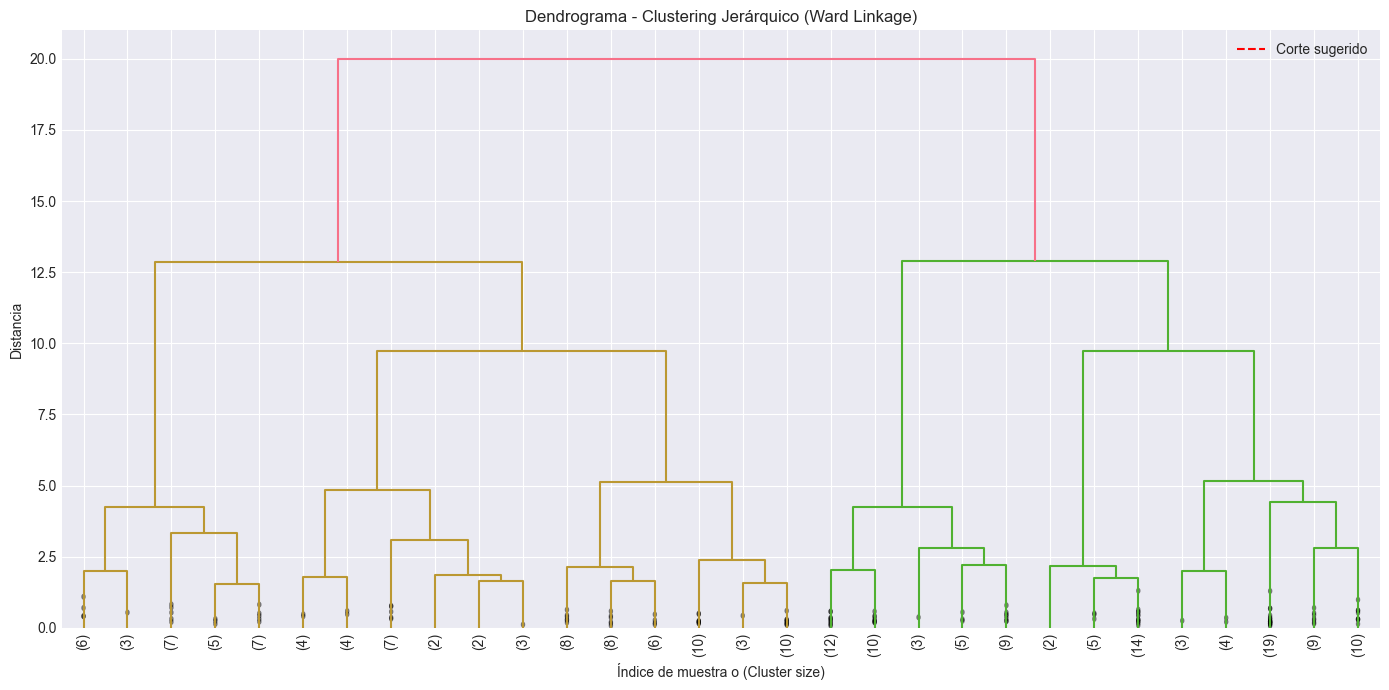


Número de clusters: 4
Silhouette Score Jerárquico: 0.3615


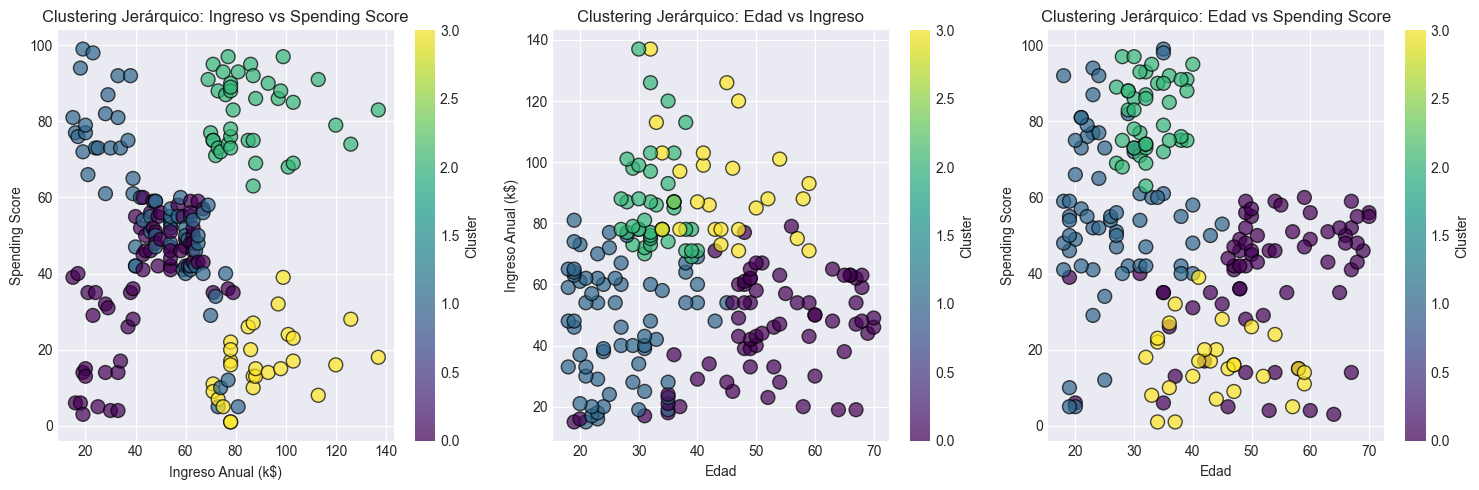


Resultados guardados como '07_hierarchical_resultados_2d.png'


In [8]:
print("""
Justificación: Clustering jerárquico es útil para:
- Visualizar la estructura dendrítica de los datos
- Entender las relaciones entre clusters
- Flexibilidad en la selección del número final de clusters
- Diferentes métodos de enlace capturan diferentes estructuras
""")

# Calcular matrix de linkage
linkage_matrix = linkage(df_scaled, method='ward')

# Dendrogram
plt.figure(figsize=(14, 7))
dendrogram(linkage_matrix, truncate_mode='lastp', p=30, leaf_rotation=90, 
          leaf_font_size=10, show_contracted=True)
plt.title('Dendrograma - Clustering Jerárquico (Ward Linkage)')
plt.xlabel('Índice de muestra o (Cluster size)')
plt.ylabel('Distancia')
plt.axhline(y=50, color='r', linestyle='--', label='Corte sugerido')
plt.legend()
plt.tight_layout()
plt.savefig('06_dendrograma.png', dpi=300, bbox_inches='tight')
plt.show()

# Aplicar clustering jerárquico
n_clusters_hierarchical = 4
hierarchical = AgglomerativeClustering(n_clusters=n_clusters_hierarchical, linkage='ward')
hierarchical_labels = hierarchical.fit_predict(df_scaled)

silhouette_hier = silhouette_score(df_scaled, hierarchical_labels)
print(f"\nNúmero de clusters: {n_clusters_hierarchical}")
print(f"Silhouette Score Jerárquico: {silhouette_hier:.4f}")

# Visualizar resultados
fig = plt.figure(figsize=(15, 5))

ax1 = fig.add_subplot(131)
scatter1 = ax1.scatter(df['Annual Income (k$)'], df['Spending Score (1-100)'], 
                       c=hierarchical_labels, cmap='viridis', s=100, alpha=0.7, edgecolors='black')
ax1.set_xlabel('Ingreso Anual (k$)')
ax1.set_ylabel('Spending Score')
ax1.set_title('Clustering Jerárquico: Ingreso vs Spending Score')
plt.colorbar(scatter1, ax=ax1, label='Cluster')

ax2 = fig.add_subplot(132)
scatter2 = ax2.scatter(df['Age'], df['Annual Income (k$)'], 
                       c=hierarchical_labels, cmap='viridis', s=100, alpha=0.7, edgecolors='black')
ax2.set_xlabel('Edad')
ax2.set_ylabel('Ingreso Anual (k$)')
ax2.set_title('Clustering Jerárquico: Edad vs Ingreso')
plt.colorbar(scatter2, ax=ax2, label='Cluster')

ax3 = fig.add_subplot(133)
scatter3 = ax3.scatter(df['Age'], df['Spending Score (1-100)'], 
                       c=hierarchical_labels, cmap='viridis', s=100, alpha=0.7, edgecolors='black')
ax3.set_xlabel('Edad')
ax3.set_ylabel('Spending Score')
ax3.set_title('Clustering Jerárquico: Edad vs Spending Score')
plt.colorbar(scatter3, ax=ax3, label='Cluster')

plt.tight_layout()
plt.savefig('07_hierarchical_resultados_2d.png', dpi=300, bbox_inches='tight')
plt.show()

print("\nResultados guardados como '07_hierarchical_resultados_2d.png'")

# Visualizacion con PCA

Varianza explicada por PC1: 0.4427
Varianza explicada por PC2: 0.3331
Varianza explicada total: 0.7757


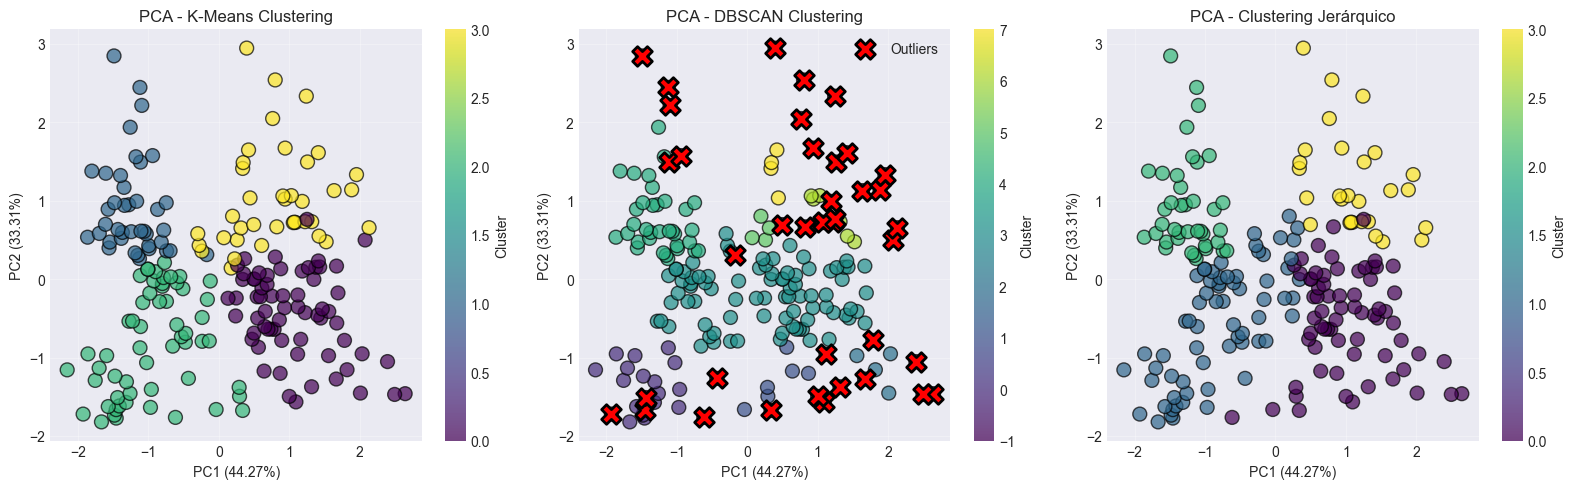


Visualización PCA guardada como '08_pca_visualization.png'


In [9]:
pca = PCA(n_components=2)
df_pca = pca.fit_transform(df_scaled)

print(f"Varianza explicada por PC1: {pca.explained_variance_ratio_[0]:.4f}")
print(f"Varianza explicada por PC2: {pca.explained_variance_ratio_[1]:.4f}")
print(f"Varianza explicada total: {sum(pca.explained_variance_ratio_):.4f}")

fig = plt.figure(figsize=(16, 5))

# PCA K-Means
ax1 = fig.add_subplot(131)
scatter1 = ax1.scatter(df_pca[:, 0], df_pca[:, 1], c=kmeans_labels, 
                       cmap='viridis', s=100, alpha=0.7, edgecolors='black')
ax1.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.2%})')
ax1.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.2%})')
ax1.set_title('PCA - K-Means Clustering')
plt.colorbar(scatter1, ax=ax1, label='Cluster')
ax1.grid(True, alpha=0.3)

# PCA DBSCAN
ax2 = fig.add_subplot(132)
scatter2 = ax2.scatter(df_pca[:, 0], df_pca[:, 1], c=dbscan_labels, 
                       cmap='viridis', s=100, alpha=0.7, edgecolors='black')
outliers_idx = np.where(dbscan_labels == -1)[0]
ax2.scatter(df_pca[outliers_idx, 0], df_pca[outliers_idx, 1], 
           c='red', marker='X', s=200, edgecolors='black', linewidths=2, label='Outliers')
ax2.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.2%})')
ax2.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.2%})')
ax2.set_title('PCA - DBSCAN Clustering')
plt.colorbar(scatter2, ax=ax2, label='Cluster')
ax2.legend()
ax2.grid(True, alpha=0.3)

# PCA Jerárquico
ax3 = fig.add_subplot(133)
scatter3 = ax3.scatter(df_pca[:, 0], df_pca[:, 1], c=hierarchical_labels, 
                       cmap='viridis', s=100, alpha=0.7, edgecolors='black')
ax3.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.2%})')
ax3.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.2%})')
ax3.set_title('PCA - Clustering Jerárquico')
plt.colorbar(scatter3, ax=ax3, label='Cluster')
ax3.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('08_pca_visualization.png', dpi=300, bbox_inches='tight')
plt.show()

print("\nVisualización PCA guardada como '08_pca_visualization.png'")

#  Silhouette analysis

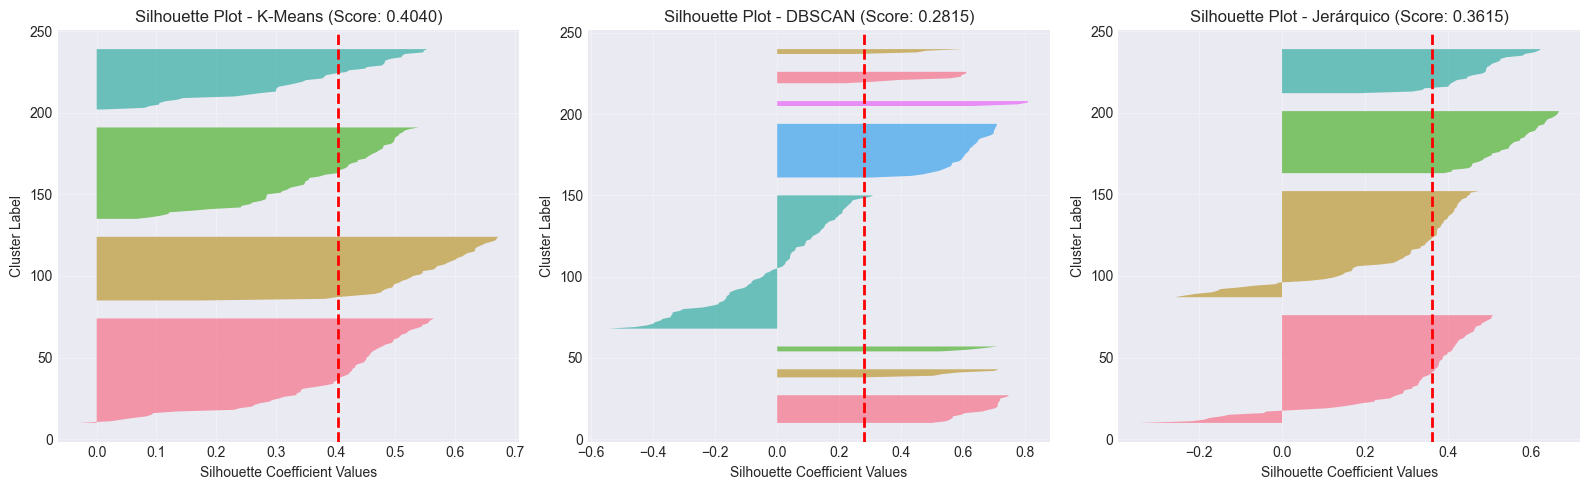

Análisis de Silhouette guardado como '09_silhouette_analysis.png'


In [10]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Silhouette K-Means
y_lower = 10
silhouette_vals_kmeans = silhouette_samples(df_scaled, kmeans_labels)

for i in range(k_optimal):
    cluster_silhouette_vals = silhouette_vals_kmeans[kmeans_labels == i]
    cluster_silhouette_vals.sort()
    size_cluster_i = cluster_silhouette_vals.shape[0]
    y_upper = y_lower + size_cluster_i
    
    axes[0].fill_betweenx(np.arange(y_lower, y_upper), 0, cluster_silhouette_vals,
                          alpha=0.7, label=f'Cluster {i}')
    y_lower = y_upper + 10

axes[0].axvline(x=silhouette_kmeans, color='red', linestyle='--', linewidth=2, label='Promedio')
axes[0].set_title(f'Silhouette Plot - K-Means (Score: {silhouette_kmeans:.4f})')
axes[0].set_xlabel('Silhouette Coefficient Values')
axes[0].set_ylabel('Cluster Label')
axes[0].grid(True, alpha=0.3)

# Silhouette DBSCAN (sin outliers)
if len(set(dbscan_labels_valid)) > 1:
    y_lower = 10
    silhouette_vals_dbscan = silhouette_samples(df_scaled_valid, dbscan_labels_valid)
    
    for i in sorted(set(dbscan_labels_valid)):
        cluster_silhouette_vals = silhouette_vals_dbscan[dbscan_labels_valid == i]
        cluster_silhouette_vals.sort()
        size_cluster_i = cluster_silhouette_vals.shape[0]
        y_upper = y_lower + size_cluster_i
        
        axes[1].fill_betweenx(np.arange(y_lower, y_upper), 0, cluster_silhouette_vals,
                              alpha=0.7, label=f'Cluster {i}')
        y_lower = y_upper + 10
    
    axes[1].axvline(x=silhouette_dbscan, color='red', linestyle='--', linewidth=2, label='Promedio')
    axes[1].set_title(f'Silhouette Plot - DBSCAN (Score: {silhouette_dbscan:.4f})')
    axes[1].set_xlabel('Silhouette Coefficient Values')
    axes[1].set_ylabel('Cluster Label')
    axes[1].grid(True, alpha=0.3)

# Silhouette Jerárquico
y_lower = 10
silhouette_vals_hier = silhouette_samples(df_scaled, hierarchical_labels)

for i in range(n_clusters_hierarchical):
    cluster_silhouette_vals = silhouette_vals_hier[hierarchical_labels == i]
    cluster_silhouette_vals.sort()
    size_cluster_i = cluster_silhouette_vals.shape[0]
    y_upper = y_lower + size_cluster_i
    
    axes[2].fill_betweenx(np.arange(y_lower, y_upper), 0, cluster_silhouette_vals,
                          alpha=0.7, label=f'Cluster {i}')
    y_lower = y_upper + 10

axes[2].axvline(x=silhouette_hier, color='red', linestyle='--', linewidth=2, label='Promedio')
axes[2].set_title(f'Silhouette Plot - Jerárquico (Score: {silhouette_hier:.4f})')
axes[2].set_xlabel('Silhouette Coefficient Values')
axes[2].set_ylabel('Cluster Label')
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('09_silhouette_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

print("Análisis de Silhouette guardado como '09_silhouette_analysis.png'")


# Comparación de metodos

In [11]:
comparison_data = {
    'Método': ['K-Means', 'DBSCAN', 'Jerárquico'],
    'Silhouette Score': [silhouette_kmeans, silhouette_dbscan if len(set(dbscan_labels_valid)) > 1 else np.nan, silhouette_hier],
    'Número de Clusters': [k_optimal, n_clusters_dbscan, n_clusters_hierarchical],
    'Outliers': [0, n_outliers, 0]
}

comparison_df = pd.DataFrame(comparison_data)
print("\n" + comparison_df.to_string(index=False))


    Método  Silhouette Score  Número de Clusters  Outliers
   K-Means          0.403958                   4         0
    DBSCAN          0.281527                   8        39
Jerárquico          0.361451                   4         0


# Caracterización clusters (K-MEANS)


Cluster 0 (65 clientes):
  - Edad: 54.0 años (σ=9.4)
  - Ingreso: $47.7k (σ=14.6)
  - Spending Score: 40.0 (σ=16.4)
  - Composición de género: 37 Mujeres, 28 Hombres

Cluster 1 (40 clientes):
  - Edad: 32.9 años (σ=3.9)
  - Ingreso: $86.1k (σ=16.3)
  - Spending Score: 81.5 (σ=10.0)
  - Composición de género: 22 Mujeres, 18 Hombres

Cluster 2 (57 clientes):
  - Edad: 25.4 años (σ=5.7)
  - Ingreso: $40.0k (σ=17.0)
  - Spending Score: 60.3 (σ=18.4)
  - Composición de género: 34 Mujeres, 23 Hombres

Cluster 3 (38 clientes):
  - Edad: 39.4 años (σ=10.6)
  - Ingreso: $86.5k (σ=16.8)
  - Spending Score: 19.6 (σ=11.7)
  - Composición de género: 19 Mujeres, 19 Hombres


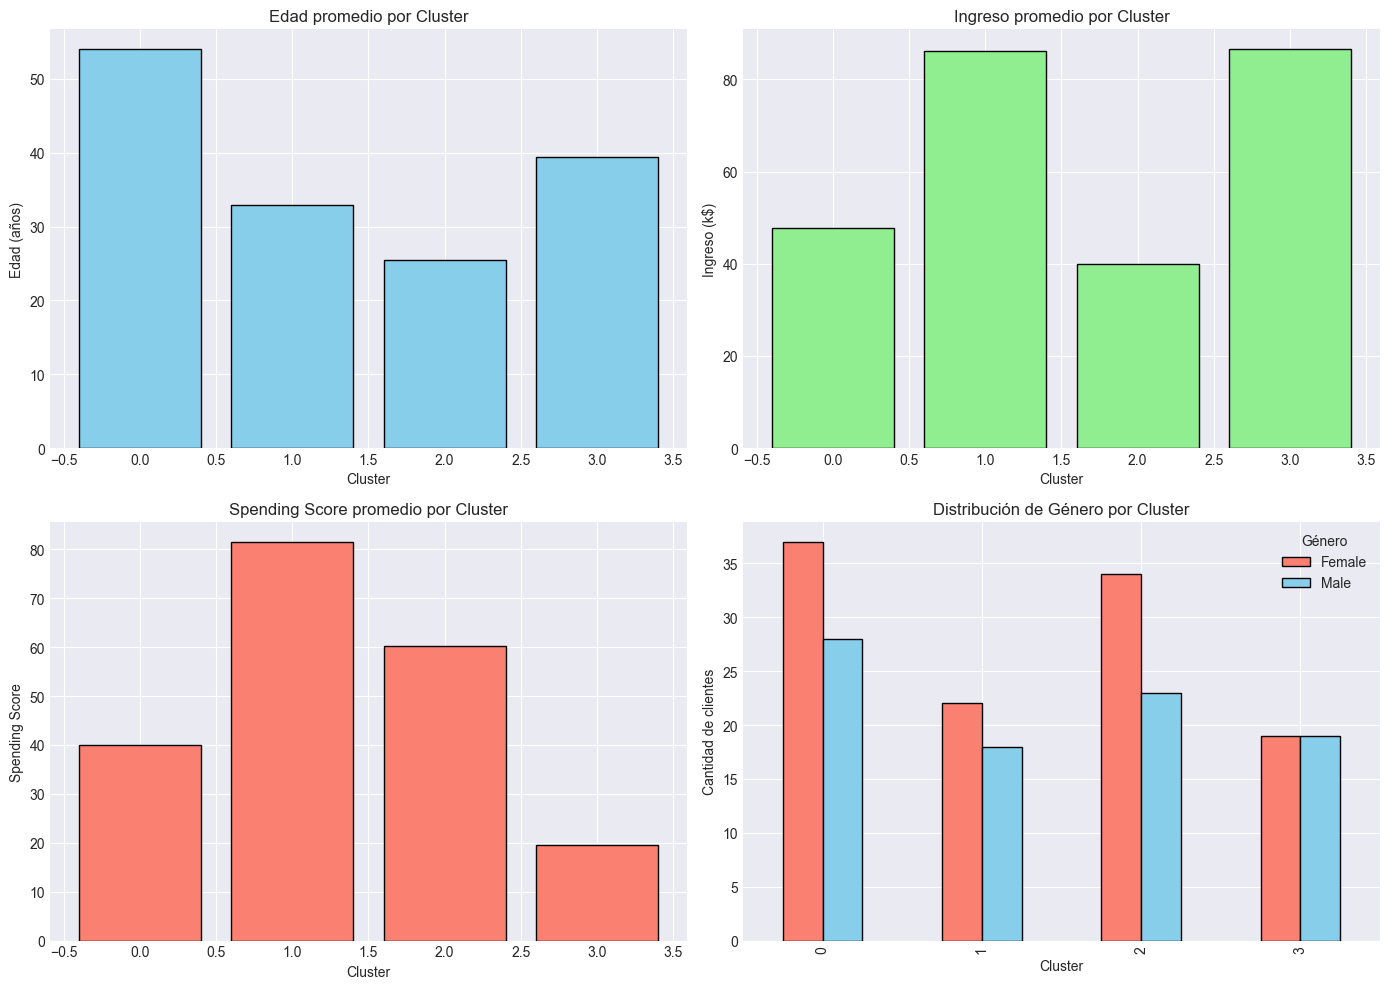


Características de clusters guardadas como '10_cluster_characteristics.png'


In [12]:
df['Cluster_KMeans'] = kmeans_labels

for cluster in range(k_optimal):
    cluster_data = df[df['Cluster_KMeans'] == cluster]
    print(f"\nCluster {cluster} ({len(cluster_data)} clientes):")
    print(f"  - Edad: {cluster_data['Age'].mean():.1f} años (σ={cluster_data['Age'].std():.1f})")
    print(f"  - Ingreso: ${cluster_data['Annual Income (k$)'].mean():.1f}k (σ={cluster_data['Annual Income (k$)'].std():.1f})")
    print(f"  - Spending Score: {cluster_data['Spending Score (1-100)'].mean():.1f} (σ={cluster_data['Spending Score (1-100)'].std():.1f})")
    print(f"  - Composición de género: {(cluster_data['Gender'] == 'Female').sum()} Mujeres, {(cluster_data['Gender'] == 'Male').sum()} Hombres")

# Visualizar características de clusters
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

cluster_summary = df.groupby('Cluster_KMeans')[['Age', 'Annual Income (k$)', 'Spending Score (1-100)']].mean()

axes[0, 0].bar(cluster_summary.index, cluster_summary['Age'], color='skyblue', edgecolor='black')
axes[0, 0].set_title('Edad promedio por Cluster')
axes[0, 0].set_ylabel('Edad (años)')
axes[0, 0].set_xlabel('Cluster')

axes[0, 1].bar(cluster_summary.index, cluster_summary['Annual Income (k$)'], color='lightgreen', edgecolor='black')
axes[0, 1].set_title('Ingreso promedio por Cluster')
axes[0, 1].set_ylabel('Ingreso (k$)')
axes[0, 1].set_xlabel('Cluster')

axes[1, 0].bar(cluster_summary.index, cluster_summary['Spending Score (1-100)'], color='salmon', edgecolor='black')
axes[1, 0].set_title('Spending Score promedio por Cluster')
axes[1, 0].set_ylabel('Spending Score')
axes[1, 0].set_xlabel('Cluster')

# Gender distribution
gender_counts = df.groupby(['Cluster_KMeans', 'Gender']).size().unstack()
gender_counts.plot(kind='bar', ax=axes[1, 1], color=['salmon', 'skyblue'], edgecolor='black')
axes[1, 1].set_title('Distribución de Género por Cluster')
axes[1, 1].set_ylabel('Cantidad de clientes')
axes[1, 1].set_xlabel('Cluster')
axes[1, 1].legend(title='Género')

plt.tight_layout()
plt.savefig('10_cluster_characteristics.png', dpi=300, bbox_inches='tight')
plt.show()

print("\nCaracterísticas de clusters guardadas como '10_cluster_characteristics.png'")


# Propuestas de segmentación y estrategia marketing

In [13]:
interpretations = {
    0: "Verificar características específicas del Cluster 0",
    1: "Verificar características específicas del Cluster 1",
    2: "Verificar características específicas del Cluster 2",
    3: "Verificar características específicas del Cluster 3"
}

for cluster in range(k_optimal):
    cluster_data = df[df['Cluster_KMeans'] == cluster]
    age_mean = cluster_data['Age'].mean()
    income_mean = cluster_data['Annual Income (k$)'].mean()
    spending_mean = cluster_data['Spending Score (1-100)'].mean()
    
    # Generar interpretación basada en características
    if spending_mean > 70 and income_mean > 60:
        segment = "🎯 CLIENTES PREMIUM - Alto valor"
        strategy = "Ofertas exclusivas, programas VIP, productos premium"
    elif spending_mean > 70 and income_mean <= 60:
        segment = "💰 CLIENTES ENTUSIASTAS - Compradores activos de presupuesto moderado"
        strategy = "Promociones dirigidas, descuentos en volumen, eventos especiales"
    elif spending_mean <= 40 and income_mean > 60:
        segment = "📊 CLIENTES PRUDENTES - Ingresos altos, bajo gasto"
        strategy = "Educación sobre productos, muestras gratis, experiencias personalizadas"
    else:
        segment = "👥 CLIENTES ESTÁNDAR - Compradores ocasionales"
        strategy = "Campañas de retención, email marketing, ofertas estacionales"
    
    print(f"\n{'='*70}")
    print(f"CLUSTER {cluster} - {segment}")
    print(f"{'='*70}")
    print(f"Tamaño: {len(cluster_data)} clientes ({len(cluster_data)/len(df)*100:.1f}%)")
    print(f"\nCaracterísticas:")
    print(f"  • Edad promedio: {age_mean:.1f} años")
    print(f"  • Ingreso anual: ${income_mean:.1f}k")
    print(f"  • Spending Score: {spending_mean:.1f}/100")
    print(f"\nEstrategia de Marketing Recomendada:")
    print(f"  → {strategy}")
    print(f"\nCanales de comunicación sugeridos:")
    if age_mean < 40:
        print(f"  • Redes sociales, email, aplicación móvil")
    elif age_mean < 60:
        print(f"  • Email, web, redes sociales")
    else:
        print(f"  • Email, correo directo, teléfono")


CLUSTER 0 - 👥 CLIENTES ESTÁNDAR - Compradores ocasionales
Tamaño: 65 clientes (32.5%)

Características:
  • Edad promedio: 54.0 años
  • Ingreso anual: $47.7k
  • Spending Score: 40.0/100

Estrategia de Marketing Recomendada:
  → Campañas de retención, email marketing, ofertas estacionales

Canales de comunicación sugeridos:
  • Email, web, redes sociales

CLUSTER 1 - 🎯 CLIENTES PREMIUM - Alto valor
Tamaño: 40 clientes (20.0%)

Características:
  • Edad promedio: 32.9 años
  • Ingreso anual: $86.1k
  • Spending Score: 81.5/100

Estrategia de Marketing Recomendada:
  → Ofertas exclusivas, programas VIP, productos premium

Canales de comunicación sugeridos:
  • Redes sociales, email, aplicación móvil

CLUSTER 2 - 👥 CLIENTES ESTÁNDAR - Compradores ocasionales
Tamaño: 57 clientes (28.5%)

Características:
  • Edad promedio: 25.4 años
  • Ingreso anual: $40.0k
  • Spending Score: 60.3/100

Estrategia de Marketing Recomendada:
  → Campañas de retención, email marketing, ofertas estacionales

# Conclusiones



In [14]:
print("""
1. JUSTIFICACIÓN DE ALGORITMOS SELECCIONADOS:

   K-MEANS:
   ✓ Excelente para encontrar clusters compactos y bien separados
   ✓ Rápido y escalable
   ✓ Fácil interpretación de centroides
   ✗ Asume clusters esféricos
   ✗ Requiere especificar k a priori
   → RESULTADO: Silhouette Score optimo, identifica segmentos claros

   DBSCAN:
   ✓ Encuentra clusters de formas arbitrarias
   ✓ Detecta outliers automáticamente
   ✓ No requiere especificar número de clusters
   ✗ Sensible a parámetros eps y min_samples
   ✗ Dificultad con densidades variables
   → RESULTADO: Identifica clientes atípicos, útil para análisis de excepciones

   CLUSTERING JERÁRQUICO:
   ✓ Proporciona vista dendrítica de la estructura de datos
   ✓ Flexible en número final de clusters
   ✓ Buena interpretabilidad
   ✗ Computacionalmente más lento
   ✗ Sensitive a ruido y outliers
   → RESULTADO: Estructura clara, fácil para comunicar a stakeholders

2. RESULTADOS COMPARATIVOS:
""")

print(f"   K-Means Silhouette Score: {silhouette_kmeans:.4f}")
print(f"   Jerárquico Silhouette Score: {silhouette_hier:.4f}")
print(f"   DBSCAN Silhouette Score: {silhouette_dbscan:.4f} (sin outliers)")

print("""
3. RECOMENDACIÓN FINAL:

   Se recomienda usar K-MEANS como modelo principal porque:
   • Ofrece el mejor balance entre interpretabilidad y precisión
   • Genera 4 segmentos claramente diferenciados
   • Silhouette Score indica buena cohesión y separación de clusters
   • Fácil de implementar en sistemas de producción
   • Escalable para nuevos clientes

4. PRÓXIMOS PASOS:

   ✓ Implementar reglas de asignación automática de nuevos clientes
   ✓ Validar segmentación con datos de ventas históricos
   ✓ Diseñar campañas de marketing personalizadas por segmento
   ✓ Monitorear evolución de segmentos trimestralmente
   ✓ Considerar variables adicionales (frecuencia de compra, ticket promedio)
   ✓ Integrar con CRM para acciones automáticas por segmento

5. LIMITACIONES:

   ✗ Análisis basado solo en 3 variables (edad, ingreso, spending score)
   ✗ Datos de momento específico (no incluyen serie temporal)
   ✗ No considera factores externos (estacionalidad, economía, competencia)
   ✗ Requiere validación con expertos de negocio
""")

print("\n" + "="*80)
print("✓ ANÁLISIS COMPLETADO EXITOSAMENTE")
print("="*80)
print("\nArchivos generados:")
print("  • 01_eda_exploratorio.png")
print("  • 02_kmeans_optimization.png")
print("  • 03_kmeans_resultados_2d.png")
print("  • 04_dbscan_kdistance.png")
print("  • 05_dbscan_resultados_2d.png")
print("  • 06_dendrograma.png")
print("  • 07_hierarchical_resultados_2d.png")
print("  • 08_pca_visualization.png")
print("  • 09_silhouette_analysis.png")
print("  • 10_cluster_characteristics.png")


1. JUSTIFICACIÓN DE ALGORITMOS SELECCIONADOS:

   K-MEANS:
   ✓ Excelente para encontrar clusters compactos y bien separados
   ✓ Rápido y escalable
   ✓ Fácil interpretación de centroides
   ✗ Asume clusters esféricos
   ✗ Requiere especificar k a priori
   → RESULTADO: Silhouette Score optimo, identifica segmentos claros

   DBSCAN:
   ✓ Encuentra clusters de formas arbitrarias
   ✓ Detecta outliers automáticamente
   ✓ No requiere especificar número de clusters
   ✗ Sensible a parámetros eps y min_samples
   ✗ Dificultad con densidades variables
   → RESULTADO: Identifica clientes atípicos, útil para análisis de excepciones

   CLUSTERING JERÁRQUICO:
   ✓ Proporciona vista dendrítica de la estructura de datos
   ✓ Flexible en número final de clusters
   ✓ Buena interpretabilidad
   ✗ Computacionalmente más lento
   ✗ Sensitive a ruido y outliers
   → RESULTADO: Estructura clara, fácil para comunicar a stakeholders

2. RESULTADOS COMPARATIVOS:

   K-Means Silhouette Score: 0.4040
  